Clustering para o Objetivo 2:

Agrupar clientes segundo hábitos de consumo, preferências de atividades, e indicadores de bem-estar mental.

In [20]:
# Install required packages
%pip install pandas scikit-learn matplotlib umap-learn seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [50]:
# clustering_habitos_bemestar.py

import sqlite3
import pandas as pd
from datetime import datetime

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Caminho e tabela
db_path = r"C:\Users\catap\Desktop\UNI\AASE\Clustering\ScreenTimevsMentalWellness.db"
main_table = "ScreenTimevsMentalWellness"

# 1) Ler dados
conn = sqlite3.connect(db_path)
df = pd.read_sql_query(f"SELECT * FROM {main_table}", conn)
conn.close()

print("Dimensão original:", df.shape)

Dimensão original: (399, 26)


In [51]:
# 2) Colunas para o objetivo B (hábitos, atividades, bem-estar, contexto)
feature_cols = [
    "screen_time_hours",
    "work_screen_hours",
    "leisure_screen_hours",
    "sleep_hours",
    "sleep_quality_1_5",
    "exercise_minutes_per_week",
    "social_hours_per_week",
    "stress_level_0_10",
    "productivity_0_10",
    "mental_wellness_index_0_10",
    "occupation_Desempregado",
    "occupation_Empregado",
    "occupation_Estudante",
    "occupation_Reformado",
    "work_mode_Hybrid",
    "work_mode_In-person",
    "work_mode_Remote",
    "age_Jovem_16-25",
    "age_Adulto_25-50",
    "age_Senior_50-60",
]

feature_cols = [c for c in feature_cols if c in df.columns]
print("Colunas usadas no clustering (objetivo B):", feature_cols)

X = df[feature_cols].copy()
X = X.fillna(X.mean())

Colunas usadas no clustering (objetivo B): ['screen_time_hours', 'work_screen_hours', 'leisure_screen_hours', 'sleep_hours', 'sleep_quality_1_5', 'exercise_minutes_per_week', 'social_hours_per_week', 'stress_level_0_10', 'productivity_0_10', 'mental_wellness_index_0_10', 'occupation_Desempregado', 'occupation_Empregado', 'occupation_Estudante', 'occupation_Reformado', 'work_mode_Hybrid', 'work_mode_In-person', 'work_mode_Remote', 'age_Jovem_16-25', 'age_Adulto_25-50', 'age_Senior_50-60']


In [52]:
# 3) Normalizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

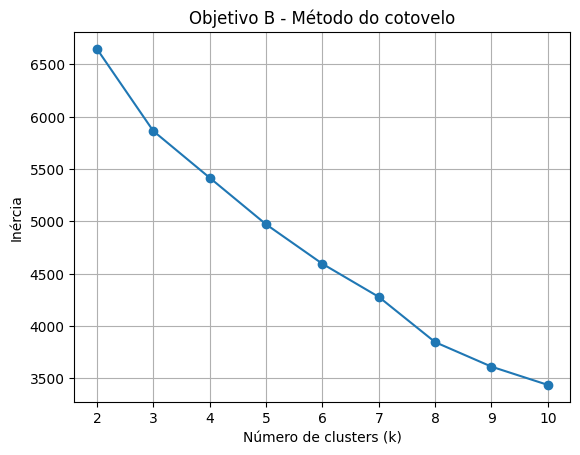

In [53]:
# 4) Método do cotovelo para escolher k
inertias = []
ks = range(2, 11)

for k in ks:
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_tmp.fit(X_scaled)
    inertias.append(km_tmp.inertia_)

plt.figure()
plt.plot(ks, inertias, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inércia")
plt.title("Objetivo B - Método do cotovelo")
plt.grid(True)
plt.show()

In [54]:
# 5) Escolher k final depois de ver o gráfico
k_final = 4  # ajusta conforme o cotovelo

kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df["cluster_habitos_bemestar"] = kmeans.fit_predict(X_scaled)

print("Número de pontos por cluster (objetivo B):")
print(df["cluster_habitos_bemestar"].value_counts().sort_index())


Número de pontos por cluster (objetivo B):
cluster_habitos_bemestar
0    109
1     85
2    117
3     88
Name: count, dtype: int64


In [55]:
# 6) Perfis médios por cluster
summary_cols = [
    "screen_time_hours",
    "sleep_hours",
    "sleep_quality_1_5",
    "exercise_minutes_per_week",
    "social_hours_per_week",
    "stress_level_0_10",
    "productivity_0_10",
    "mental_wellness_index_0_10",
]
summary_cols = [c for c in summary_cols if c in df.columns]

cluster_profile = df.groupby("cluster_habitos_bemestar")[summary_cols].mean()
print("\nPerfis médios por cluster (objetivo B):")
print(cluster_profile)


Perfis médios por cluster (objetivo B):
                          screen_time_hours  sleep_hours  sleep_quality_1_5  \
cluster_habitos_bemestar                                                      
0                                  9.536239     6.739725           1.229358   
1                                  8.838706     6.817059           1.176471   
2                                 10.599145     6.825299           1.205128   
3                                  6.363068     7.794773           2.079545   

                          exercise_minutes_per_week  social_hours_per_week  \
cluster_habitos_bemestar                                                     
0                                         99.229358               7.924771   
1                                        100.952941               8.114118   
2                                        102.769231               7.224786   
3                                        141.602273               8.672727   

               

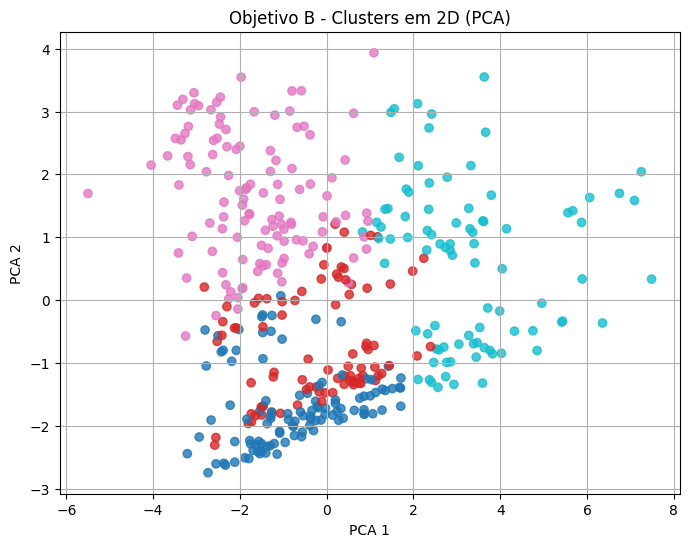

In [56]:
# 7) PCA para visualização 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df["pca1_B"] = X_pca[:, 0]
df["pca2_B"] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
plt.scatter(
    df["pca1_B"],
    df["pca2_B"],
    c=df["cluster_habitos_bemestar"],
    cmap="tab10",
    alpha=0.8
)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Objetivo B - Clusters em 2D (PCA)")
plt.grid(True)
plt.show()

c:\Users\catap\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


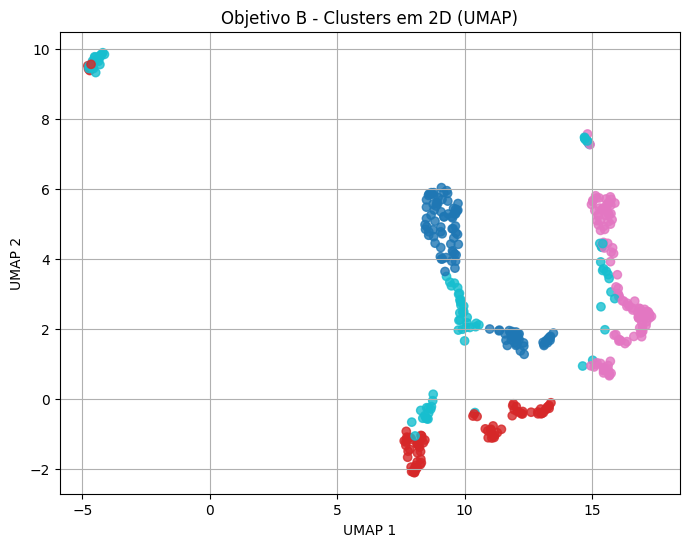

In [57]:
# 7b) UMAP para visualização 2D (alternativa ao PCA)
import umap

umap_model = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
X_umap = umap_model.fit_transform(X_scaled)

df["umap1_B"] = X_umap[:, 0]
df["umap2_B"] = X_umap[:, 1]

plt.figure(figsize=(8, 6))
plt.scatter(
    df["umap1_B"],
    df["umap2_B"],
    c=df["cluster_habitos_bemestar"],
    cmap="tab10",
    alpha=0.8
)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("Objetivo B - Clusters em 2D (UMAP)")
plt.grid(True)
plt.show()

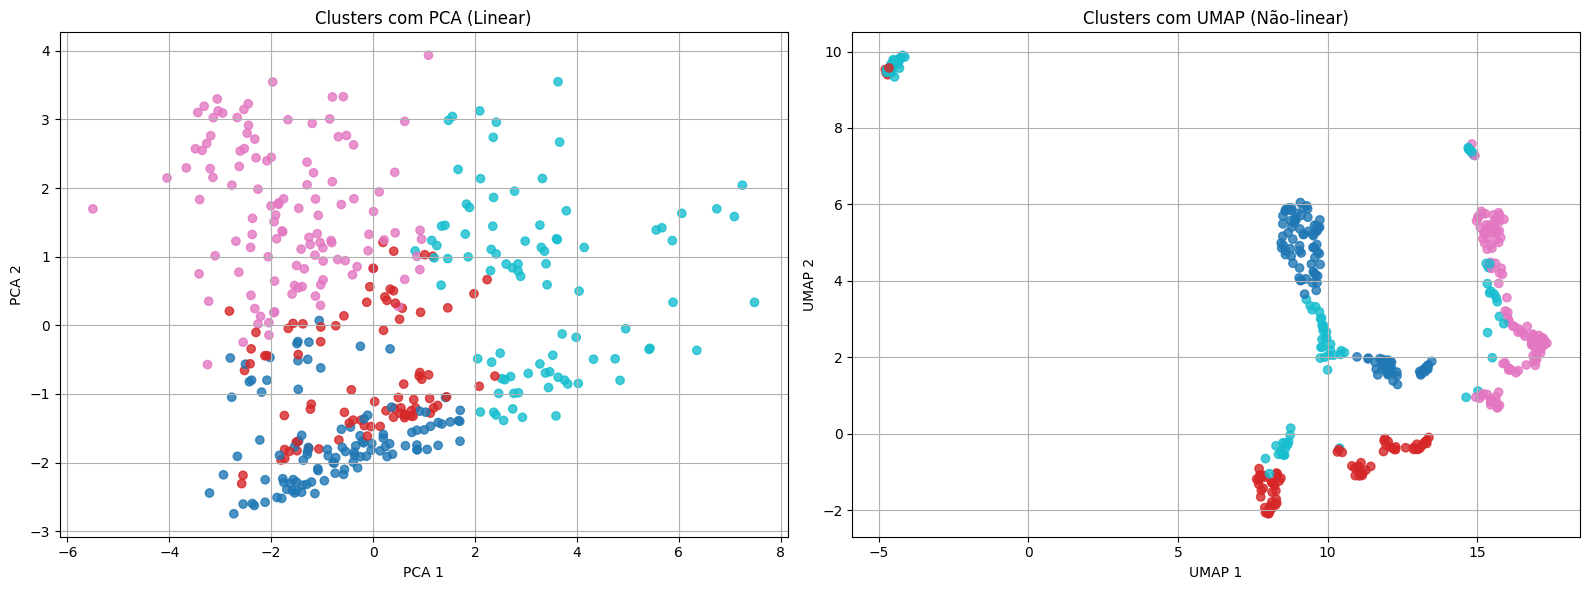

In [58]:
# 7c) Comparação lado a lado: PCA vs UMAP
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA
axes[0].scatter(
    df["pca1_B"],
    df["pca2_B"],
    c=df["cluster_habitos_bemestar"],
    cmap="tab10",
    alpha=0.8
)
axes[0].set_xlabel("PCA 1")
axes[0].set_ylabel("PCA 2")
axes[0].set_title("Clusters com PCA (Linear)")
axes[0].grid(True)

# UMAP
axes[1].scatter(
    df["umap1_B"],
    df["umap2_B"],
    c=df["cluster_habitos_bemestar"],
    cmap="tab10",
    alpha=0.8
)
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")
axes[1].set_title("Clusters com UMAP (Não-linear)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

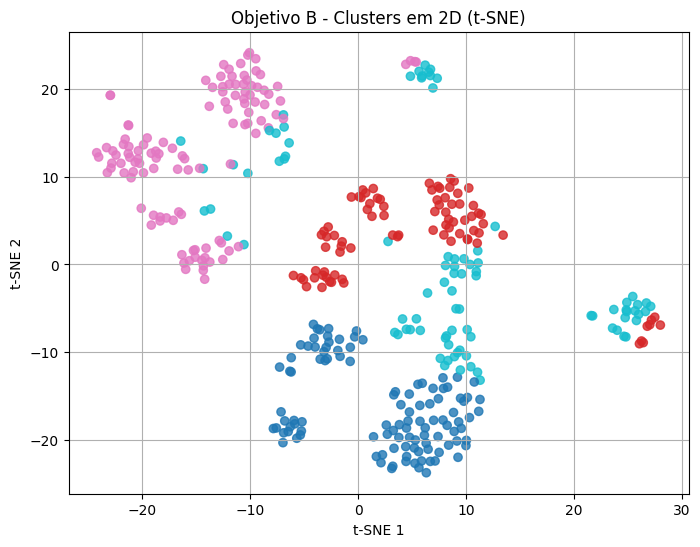

In [59]:
# 7d) t-SNE para visualização 2D
from sklearn.manifold import TSNE

# scikit-learn renamed the iteration parameter in newer versions to `max_iter`
tsne_model = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne_model.fit_transform(X_scaled)

df["tsne1_B"] = X_tsne[:, 0]
df["tsne2_B"] = X_tsne[:, 1]

plt.figure(figsize=(8, 6))
plt.scatter(
    df["tsne1_B"],
    df["tsne2_B"],
    c=df["cluster_habitos_bemestar"],
    cmap="tab10",
    alpha=0.8
)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("Objetivo B - Clusters em 2D (t-SNE)")
plt.grid(True)
plt.show()

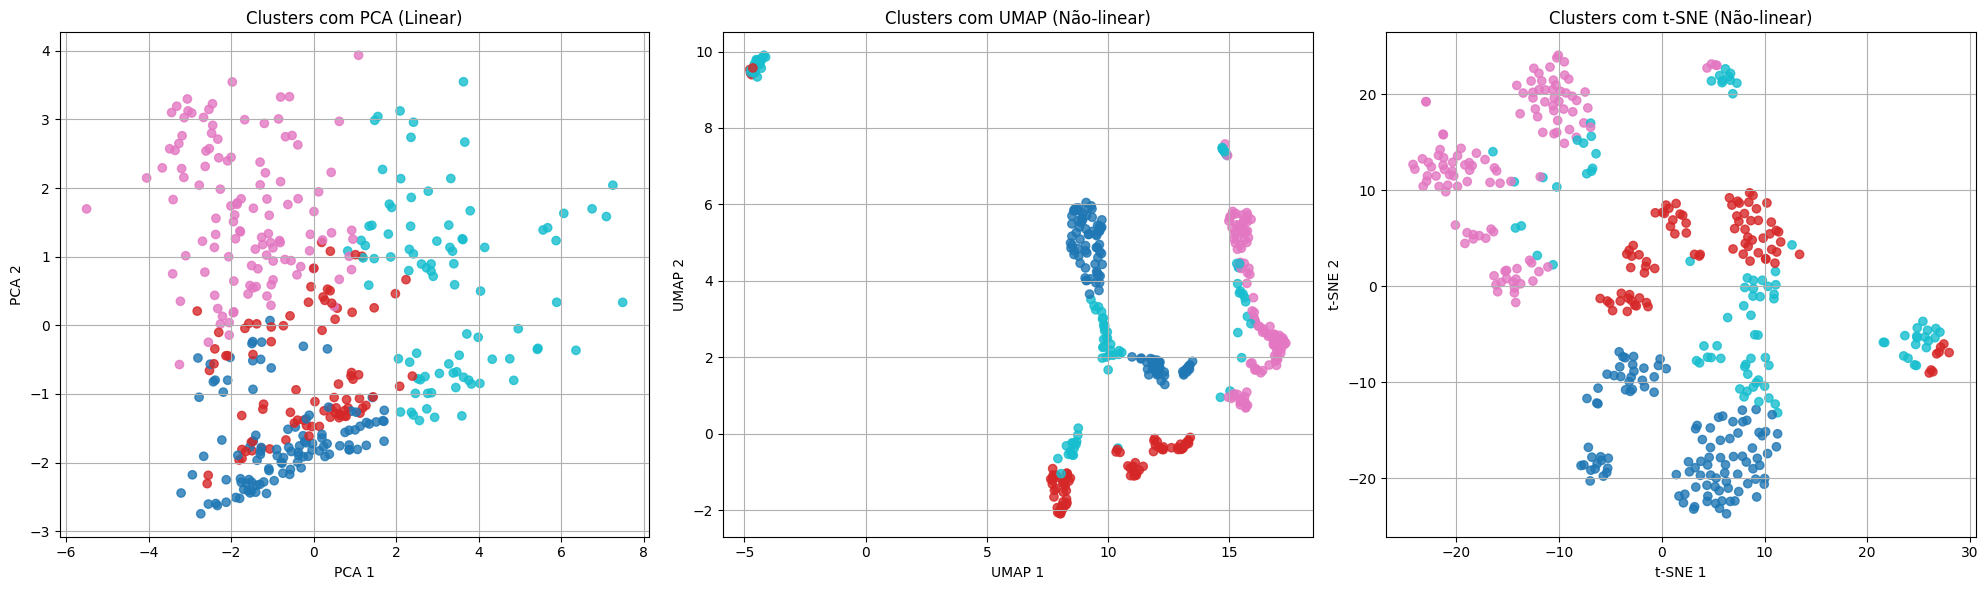

In [60]:
# 7e) Comparação PCA vs UMAP vs t-SNE
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# PCA
axes[0].scatter(
    df["pca1_B"],
    df["pca2_B"],
    c=df["cluster_habitos_bemestar"],
    cmap="tab10",
    alpha=0.8
)
axes[0].set_xlabel("PCA 1")
axes[0].set_ylabel("PCA 2")
axes[0].set_title("Clusters com PCA (Linear)")
axes[0].grid(True)

# UMAP
axes[1].scatter(
    df["umap1_B"],
    df["umap2_B"],
    c=df["cluster_habitos_bemestar"],
    cmap="tab10",
    alpha=0.8
)
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")
axes[1].set_title("Clusters com UMAP (Não-linear)")
axes[1].grid(True)

# t-SNE
axes[2].scatter(
    df["tsne1_B"],
    df["tsne2_B"],
    c=df["cluster_habitos_bemestar"],
    cmap="tab10",
    alpha=0.8
)
axes[2].set_xlabel("t-SNE 1")
axes[2].set_ylabel("t-SNE 2")
axes[2].set_title("Clusters com t-SNE (Não-linear)")
axes[2].grid(True)

plt.tight_layout()
plt.show()

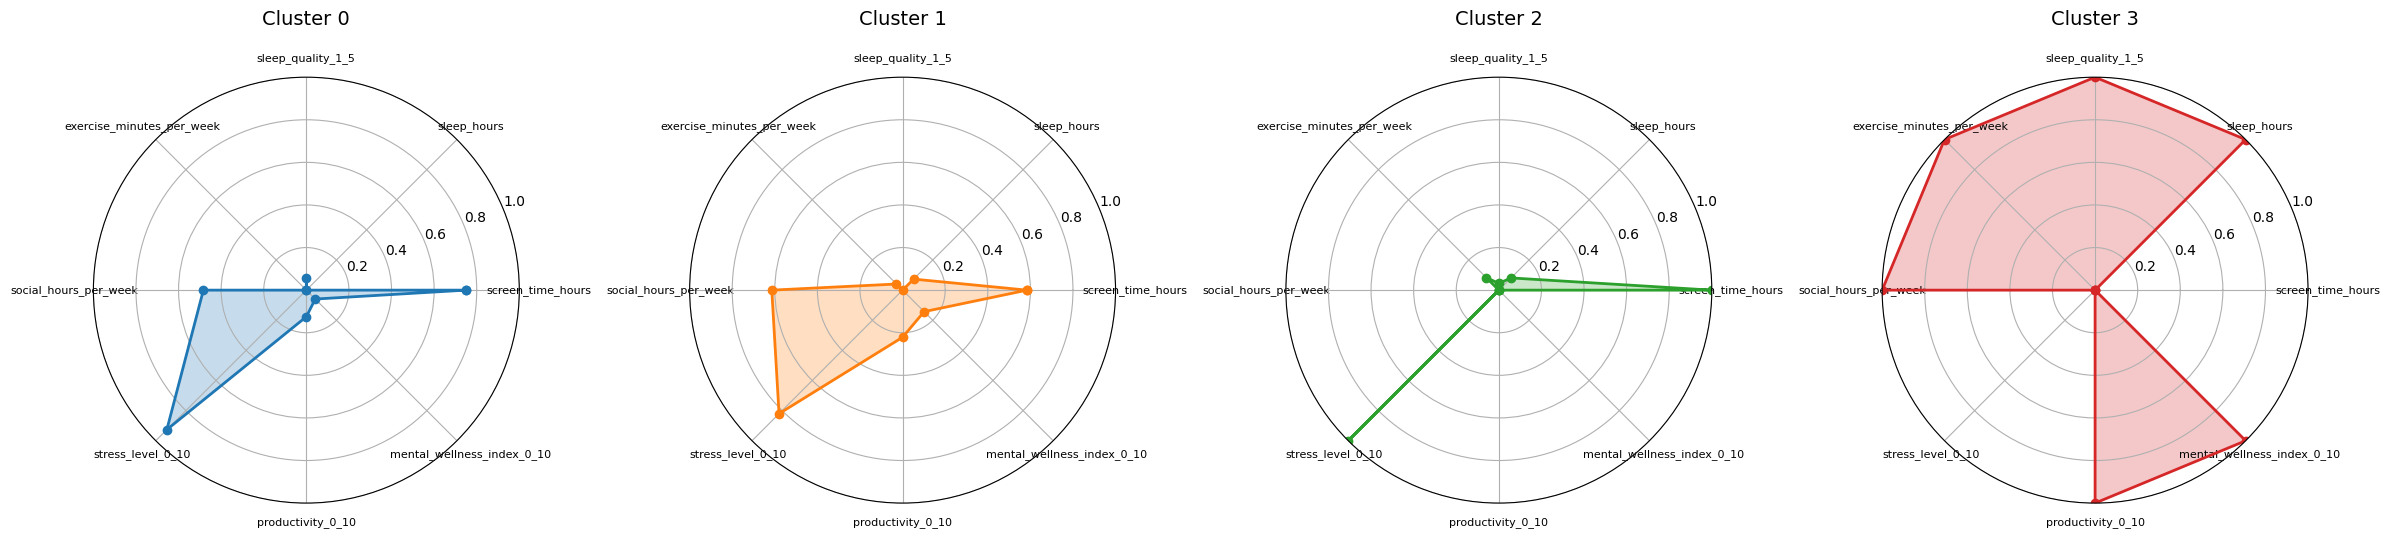

In [61]:
# 8b) Gráficos de Radar (Spider Charts) por Cluster
import numpy as np

# Preparar dados para radar chart
cluster_profile_radar = df.groupby("cluster_habitos_bemestar")[summary_cols].mean()

# Normalizar para escala 0-1
scaler_radar = MinMaxScaler()
cluster_profile_radar_norm = pd.DataFrame(
    scaler_radar.fit_transform(cluster_profile_radar),
    index=cluster_profile_radar.index,
    columns=cluster_profile_radar.columns
)

# Criar radar chart para cada cluster
num_clusters = len(cluster_profile_radar_norm)
num_vars = len(summary_cols)

# Ângulos para cada eixo
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # Fechar o círculo

# Criar subplots
fig, axes = plt.subplots(1, num_clusters, figsize=(6*num_clusters, 6), subplot_kw=dict(projection='polar'))

# Se houver apenas 1 cluster, axes não é array
if num_clusters == 1:
    axes = [axes]

colors = plt.cm.tab10(range(num_clusters))

for idx, cluster_id in enumerate(cluster_profile_radar_norm.index):
    ax = axes[idx]
    
    # Valores do cluster
    values = cluster_profile_radar_norm.loc[cluster_id].values.tolist()
    values += values[:1]  # Fechar o círculo
    
    # Plot
    ax.plot(angles, values, 'o-', linewidth=2, color=colors[idx], label=f'Cluster {cluster_id}')
    ax.fill(angles, values, alpha=0.25, color=colors[idx])
    
    # Labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(summary_cols, size=8)
    ax.set_ylim(0, 1)
    ax.set_title(f'Cluster {cluster_id}', size=14, pad=20)
    ax.grid(True)

plt.tight_layout()
plt.show()

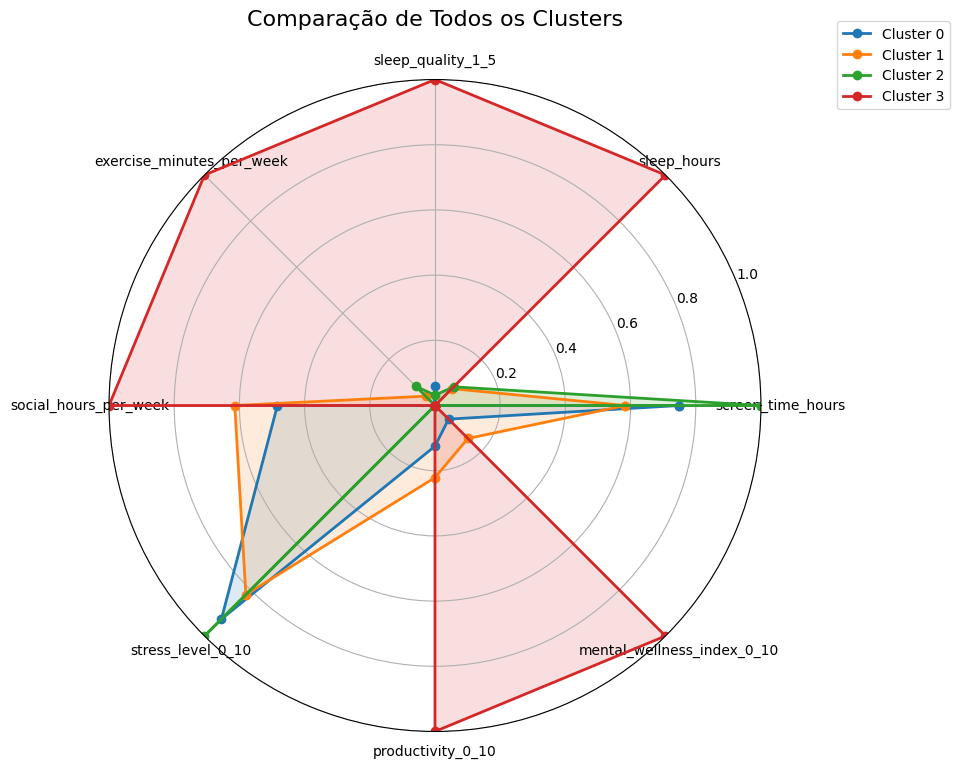

In [62]:
# 8c) Radar Chart Comparativo (todos os clusters juntos)
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='polar')

for idx, cluster_id in enumerate(cluster_profile_radar_norm.index):
    values = cluster_profile_radar_norm.loc[cluster_id].values.tolist()
    values += values[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2, color=colors[idx], label=f'Cluster {cluster_id}')
    ax.fill(angles, values, alpha=0.15, color=colors[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(summary_cols, size=10)
ax.set_ylim(0, 1)
ax.set_title('Comparação de Todos os Clusters', size=16, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.grid(True)

plt.tight_layout()
plt.show()

In [63]:
# 8d) Gráficos de Barras Empilhadas - Distribuição de Variáveis Categóricas por Cluster

# Primeiro, precisamos recuperar as colunas categóricas originais
# (antes do one-hot encoding)

# Verificar quais colunas categóricas existem no dataset
categorical_vars = []

# Verificar se temos as colunas originais ou precisamos reconstruir
if 'occupation' in df.columns:
    categorical_vars.append('occupation')
else:
    # Reconstruir occupation a partir do one-hot encoding
    occupation_cols = [c for c in df.columns if c.startswith('occupation_')]
    if occupation_cols:
        df['occupation'] = df[occupation_cols].idxmax(axis=1).str.replace('occupation_', '')
        categorical_vars.append('occupation')

if 'work_mode' in df.columns:
    categorical_vars.append('work_mode')
else:
    # Reconstruir work_mode
    work_mode_cols = [c for c in df.columns if c.startswith('work_mode_')]
    if work_mode_cols:
        df['work_mode'] = df[work_mode_cols].idxmax(axis=1).str.replace('work_mode_', '')
        categorical_vars.append('work_mode')

if 'age' in df.columns:
    categorical_vars.append('age')
else:
    # Reconstruir age
    age_cols = [c for c in df.columns if c.startswith('age_')]
    if age_cols:
        df['age'] = df[age_cols].idxmax(axis=1).str.replace('age_', '')
        categorical_vars.append('age')

print(f"Variáveis categóricas encontradas: {categorical_vars}")

Variáveis categóricas encontradas: ['occupation', 'work_mode', 'age']


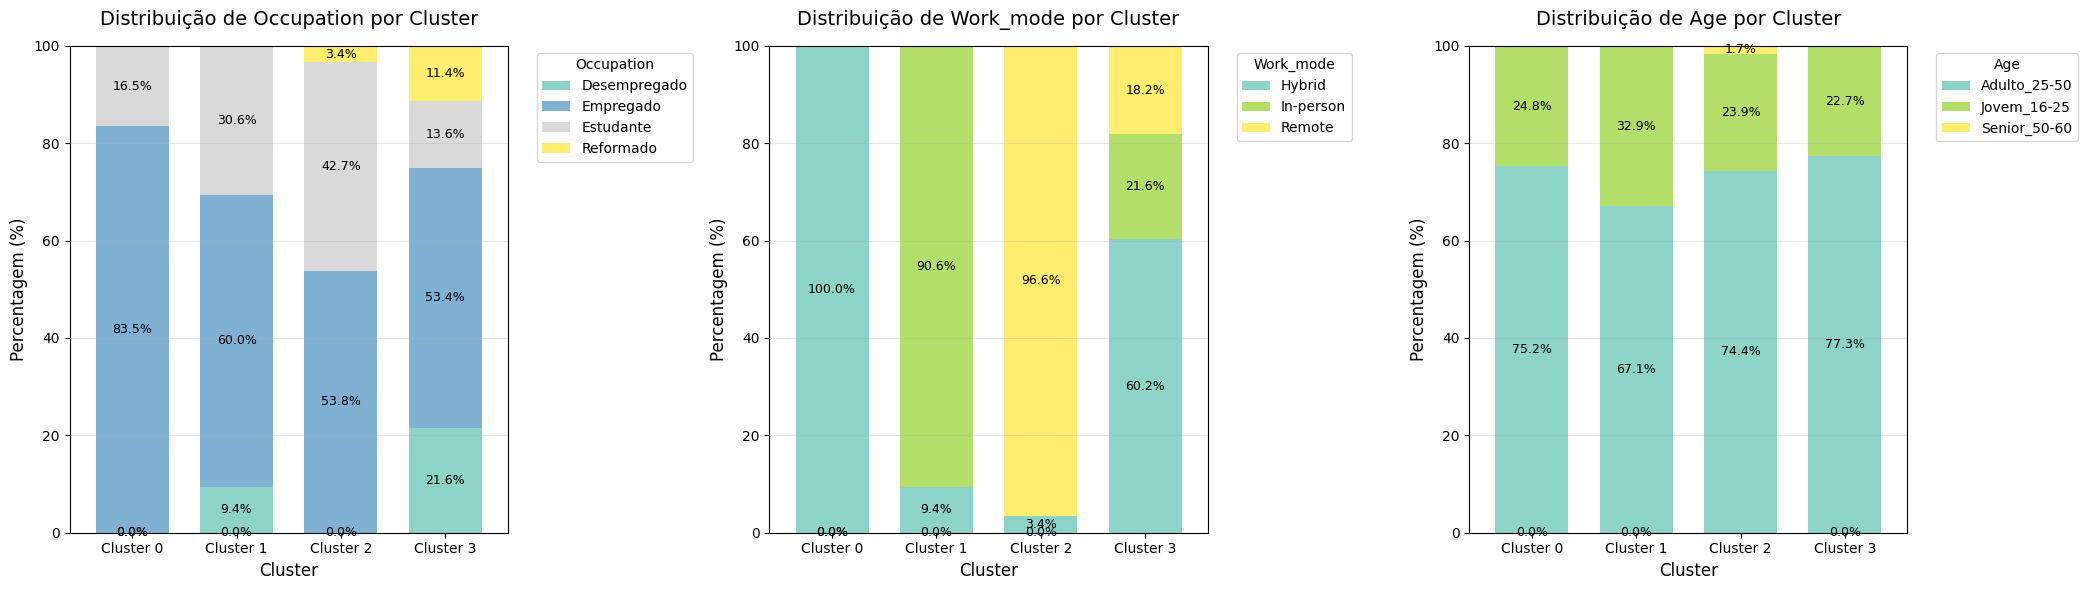


TABELAS DE DISTRIBUIÇÃO POR CLUSTER

OCCUPATION:
occupation                Desempregado  Empregado  Estudante  Reformado
cluster_habitos_bemestar                                               
0                                  0.0       83.5       16.5        0.0
1                                  9.4       60.0       30.6        0.0
2                                  0.0       53.8       42.7        3.4
3                                 21.6       53.4       13.6       11.4

WORK_MODE:
work_mode                 Hybrid  In-person  Remote
cluster_habitos_bemestar                           
0                          100.0        0.0     0.0
1                            9.4       90.6     0.0
2                            3.4        0.0    96.6
3                           60.2       21.6    18.2

AGE:
age                       Adulto_25-50  Jovem_16-25  Senior_50-60
cluster_habitos_bemestar                                         
0                                 75.2         24.8     

In [64]:
# 8e) Criar Gráficos de Barras Empilhadas com Percentagens

num_vars = len(categorical_vars)
if num_vars > 0:
    fig, axes = plt.subplots(1, num_vars, figsize=(7*num_vars, 6))
    
    # Se houver apenas 1 variável, axes não é array
    if num_vars == 1:
        axes = [axes]
    
    for idx, var in enumerate(categorical_vars):
        # Calcular contagens e percentagens
        cross_tab = pd.crosstab(df['cluster_habitos_bemestar'], df[var])
        cross_tab_pct = cross_tab.div(cross_tab.sum(axis=1), axis=0) * 100
        
        # Criar gráfico de barras empilhadas
        cross_tab_pct.plot(
            kind='bar',
            stacked=True,
            ax=axes[idx],
            colormap='Set3',
            width=0.7
        )
        
        axes[idx].set_xlabel('Cluster', fontsize=12)
        axes[idx].set_ylabel('Percentagem (%)', fontsize=12)
        axes[idx].set_title(f'Distribuição de {var.capitalize()} por Cluster', fontsize=14, pad=15)
        axes[idx].legend(title=var.capitalize(), bbox_to_anchor=(1.05, 1), loc='upper left')
        axes[idx].set_xticklabels([f'Cluster {i}' for i in cross_tab_pct.index], rotation=0)
        axes[idx].set_ylim(0, 100)
        axes[idx].grid(axis='y', alpha=0.3)
        
        # Adicionar percentagens nas barras
        for container in axes[idx].containers:
            axes[idx].bar_label(container, fmt='%.1f%%', label_type='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # Mostrar tabelas de contagens
    print("\n" + "="*60)
    print("TABELAS DE DISTRIBUIÇÃO POR CLUSTER")
    print("="*60)
    for var in categorical_vars:
        print(f"\n{var.upper()}:")
        cross_tab = pd.crosstab(df['cluster_habitos_bemestar'], df[var])
        cross_tab_pct = cross_tab.div(cross_tab.sum(axis=1), axis=0) * 100
        print(cross_tab_pct.round(1))
else:
    print("Nenhuma variável categórica encontrada no dataset.")

## Análise Detalhada dos Clusters - Comparações Visuais

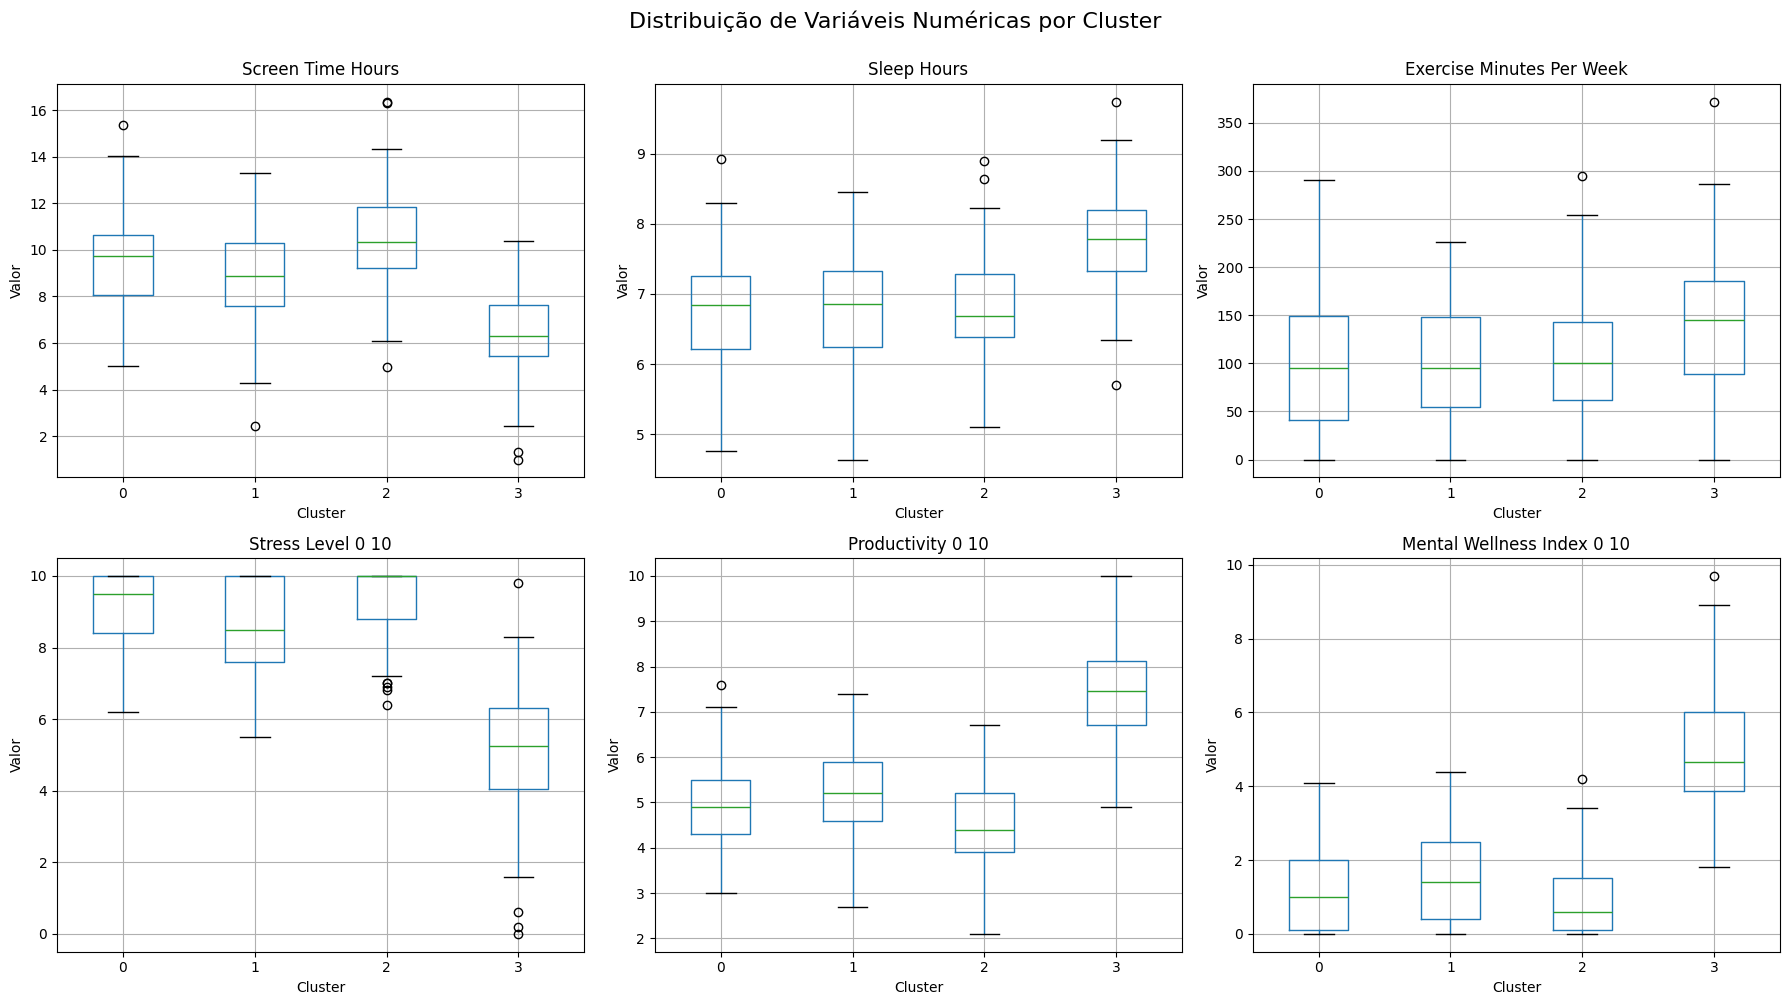

In [65]:
# 10a) Comparação de Variáveis Numéricas - Box Plots por Cluster

# Selecionar variáveis numéricas principais
numeric_vars_to_compare = [
    "screen_time_hours",
    "sleep_hours", 
    "exercise_minutes_per_week",
    "stress_level_0_10",
    "productivity_0_10",
    "mental_wellness_index_0_10"
]

numeric_vars_to_compare = [v for v in numeric_vars_to_compare if v in df.columns]

# Criar subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, var in enumerate(numeric_vars_to_compare):
    # Box plot por cluster
    df.boxplot(column=var, by='cluster_habitos_bemestar', ax=axes[idx])
    axes[idx].set_title(f'{var.replace("_", " ").title()}')
    axes[idx].set_xlabel('Cluster')
    axes[idx].set_ylabel('Valor')
    axes[idx].get_figure().suptitle('')  # Remove título automático

plt.suptitle('Distribuição de Variáveis Numéricas por Cluster', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

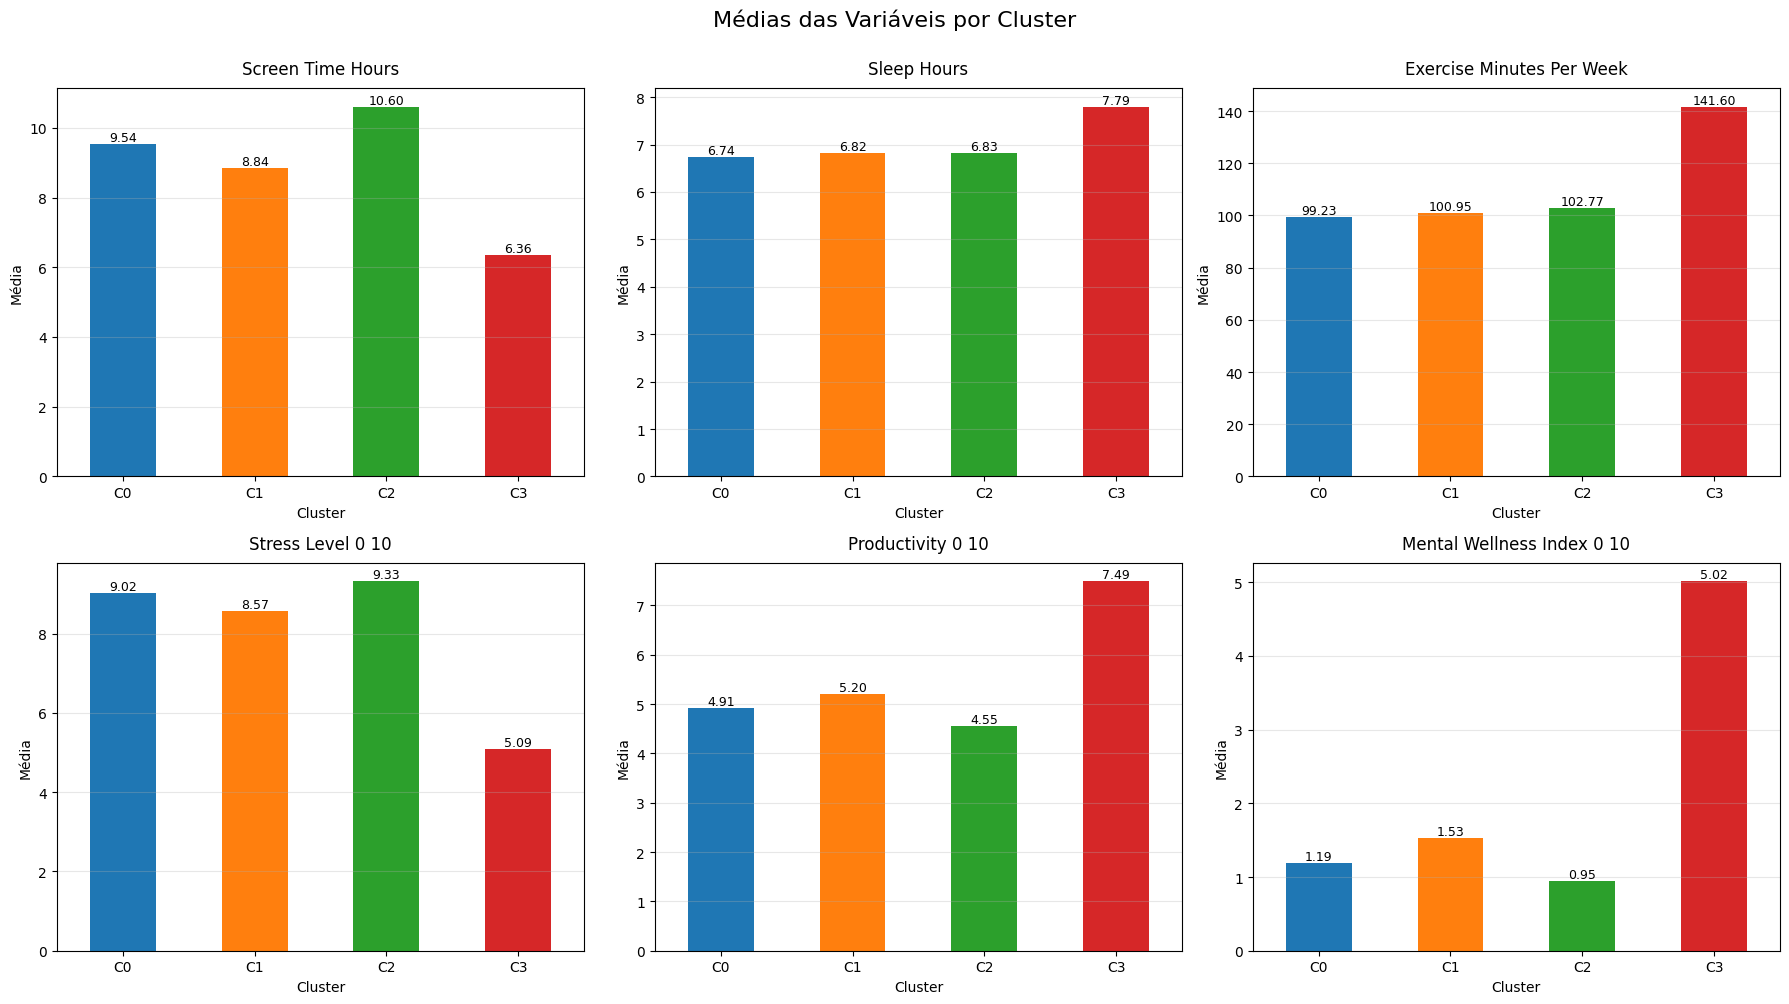

In [66]:
# 10b) Gráficos de Barras Comparativos - Médias por Cluster

# Calcular médias por cluster
cluster_means = df.groupby('cluster_habitos_bemestar')[numeric_vars_to_compare].mean()

# Criar gráficos de barras agrupadas
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, var in enumerate(numeric_vars_to_compare):
    cluster_means[var].plot(kind='bar', ax=axes[idx], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
    axes[idx].set_title(f'{var.replace("_", " ").title()}', fontsize=12, pad=10)
    axes[idx].set_xlabel('Cluster', fontsize=10)
    axes[idx].set_ylabel('Média', fontsize=10)
    axes[idx].set_xticklabels([f'C{i}' for i in cluster_means.index], rotation=0)
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Adicionar valores nas barras
    for container in axes[idx].containers:
        axes[idx].bar_label(container, fmt='%.2f', fontsize=9)

plt.suptitle('Médias das Variáveis por Cluster', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

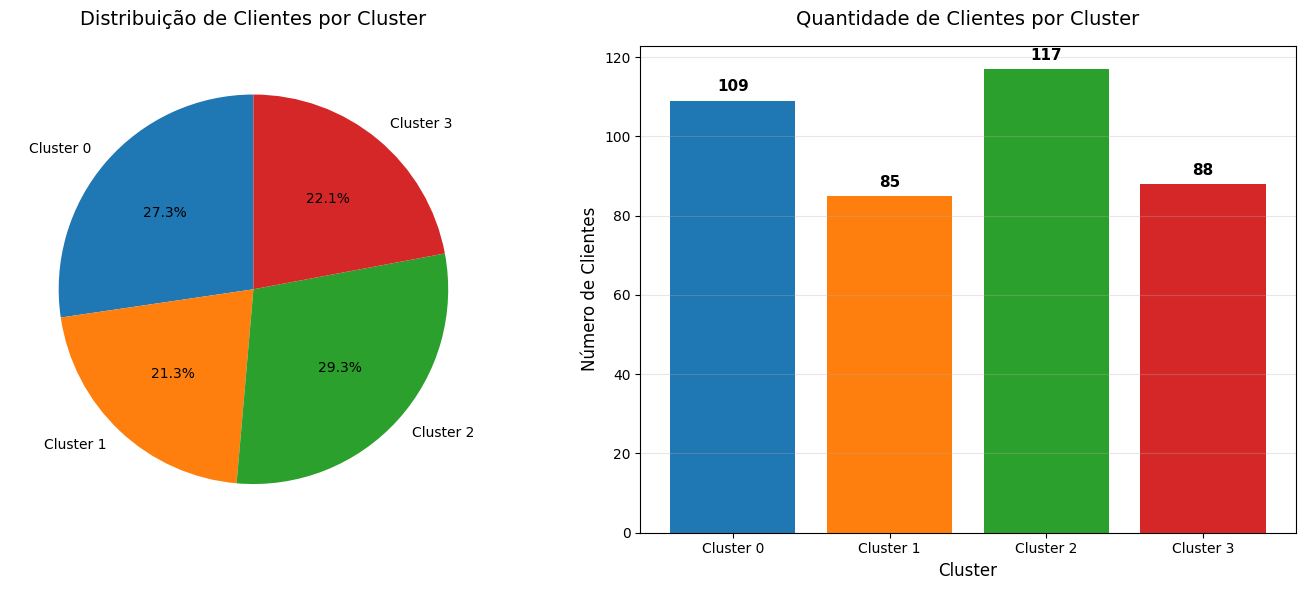


Resumo de Clientes por Cluster:
cluster_habitos_bemestar
0    109
1     85
2    117
3     88
Name: count, dtype: int64

Total de clientes: 399


In [74]:
# 10c) Tamanho dos Clusters - Gráfico de Pizza e Barras

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Contar clientes por cluster
cluster_counts = df['cluster_habitos_bemestar'].value_counts().sort_index()

# Gráfico de Pizza
colors_pie = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
axes[0].pie(cluster_counts, labels=[f'Cluster {i}' for i in cluster_counts.index], 
            autopct='%1.1f%%', startangle=90, colors=colors_pie[:len(cluster_counts)])
axes[0].set_title('Distribuição de Clientes por Cluster', fontsize=14, pad=15)

# Gráfico de Barras
axes[1].bar([f'Cluster {i}' for i in cluster_counts.index], cluster_counts, 
            color=colors_pie[:len(cluster_counts)])
axes[1].set_xlabel('Cluster', fontsize=12)
axes[1].set_ylabel('Número de Clientes', fontsize=12)
axes[1].set_title('Quantidade de Clientes por Cluster', fontsize=14, pad=15)
axes[1].grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for i, v in enumerate(cluster_counts):
    axes[1].text(i, v + max(cluster_counts)*0.02, str(v), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nResumo de Clientes por Cluster:")
print(cluster_counts)
print(f"\nTotal de clientes: {cluster_counts.sum()}")

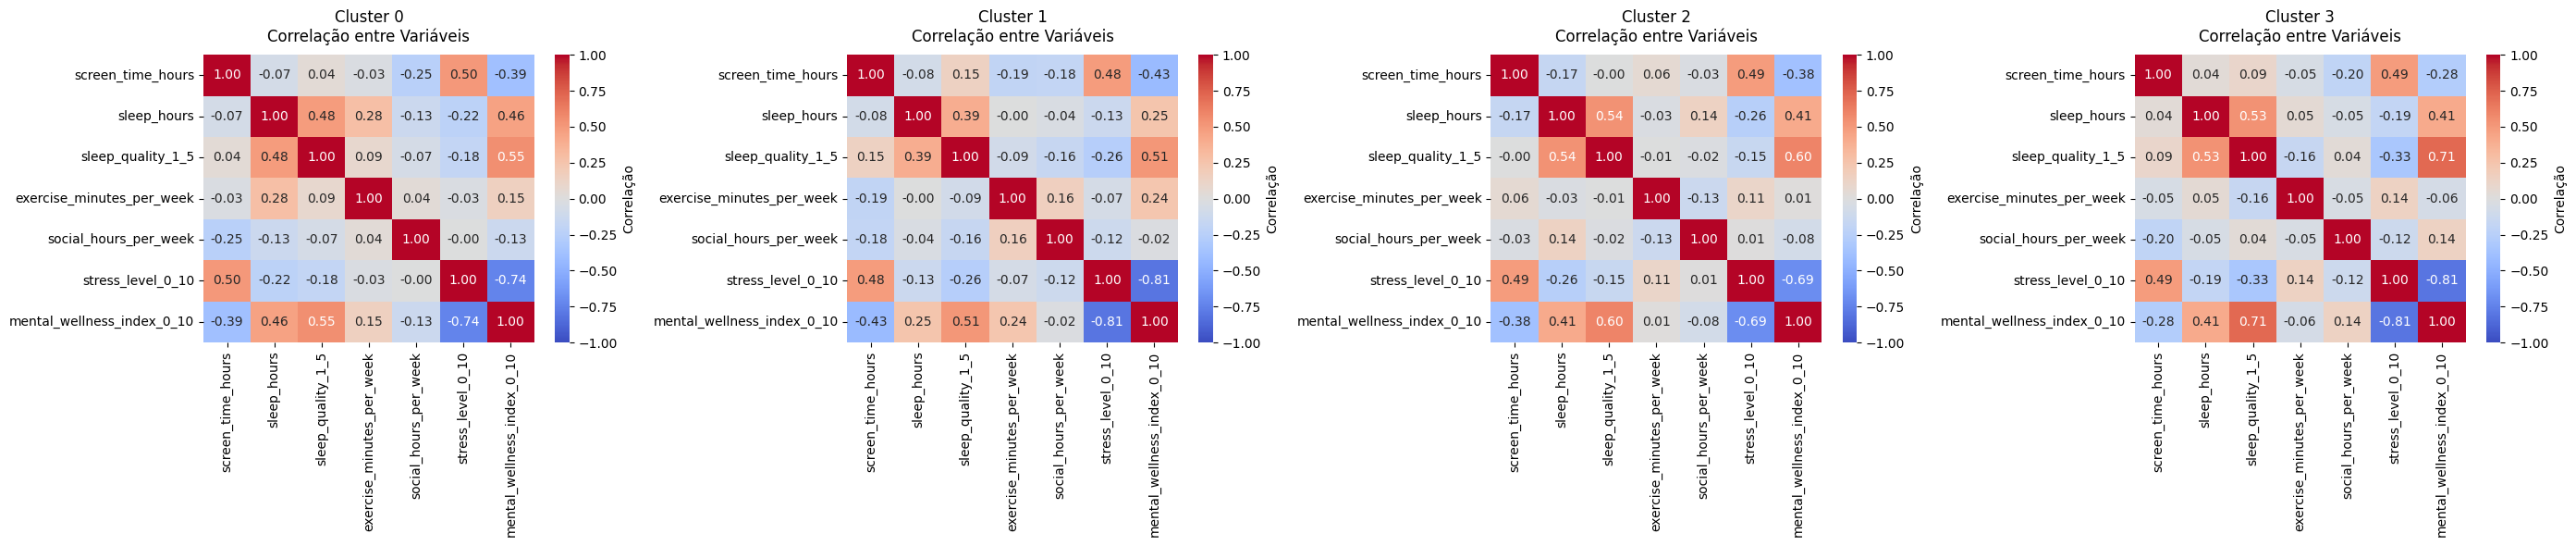

In [68]:
# 10d) Matriz de Correlação entre Bem-estar e Hábitos por Cluster

# Selecionar variáveis de interesse
correlation_vars = [
    'screen_time_hours',
    'sleep_hours',
    'sleep_quality_1_5',
    'exercise_minutes_per_week',
    'social_hours_per_week',
    'stress_level_0_10',
    'mental_wellness_index_0_10'
]
correlation_vars = [v for v in correlation_vars if v in df.columns]

# Criar heatmaps para cada cluster
num_clusters = df['cluster_habitos_bemestar'].nunique()
fig, axes = plt.subplots(1, num_clusters, figsize=(7*num_clusters, 6))

if num_clusters == 1:
    axes = [axes]

for idx, cluster_id in enumerate(sorted(df['cluster_habitos_bemestar'].unique())):
    cluster_data = df[df['cluster_habitos_bemestar'] == cluster_id][correlation_vars]
    corr_matrix = cluster_data.corr()
    
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, vmin=-1, vmax=1, ax=axes[idx],
                cbar_kws={'label': 'Correlação'})
    axes[idx].set_title(f'Cluster {cluster_id}\nCorrelação entre Variáveis', fontsize=12, pad=10)

plt.tight_layout()
plt.show()

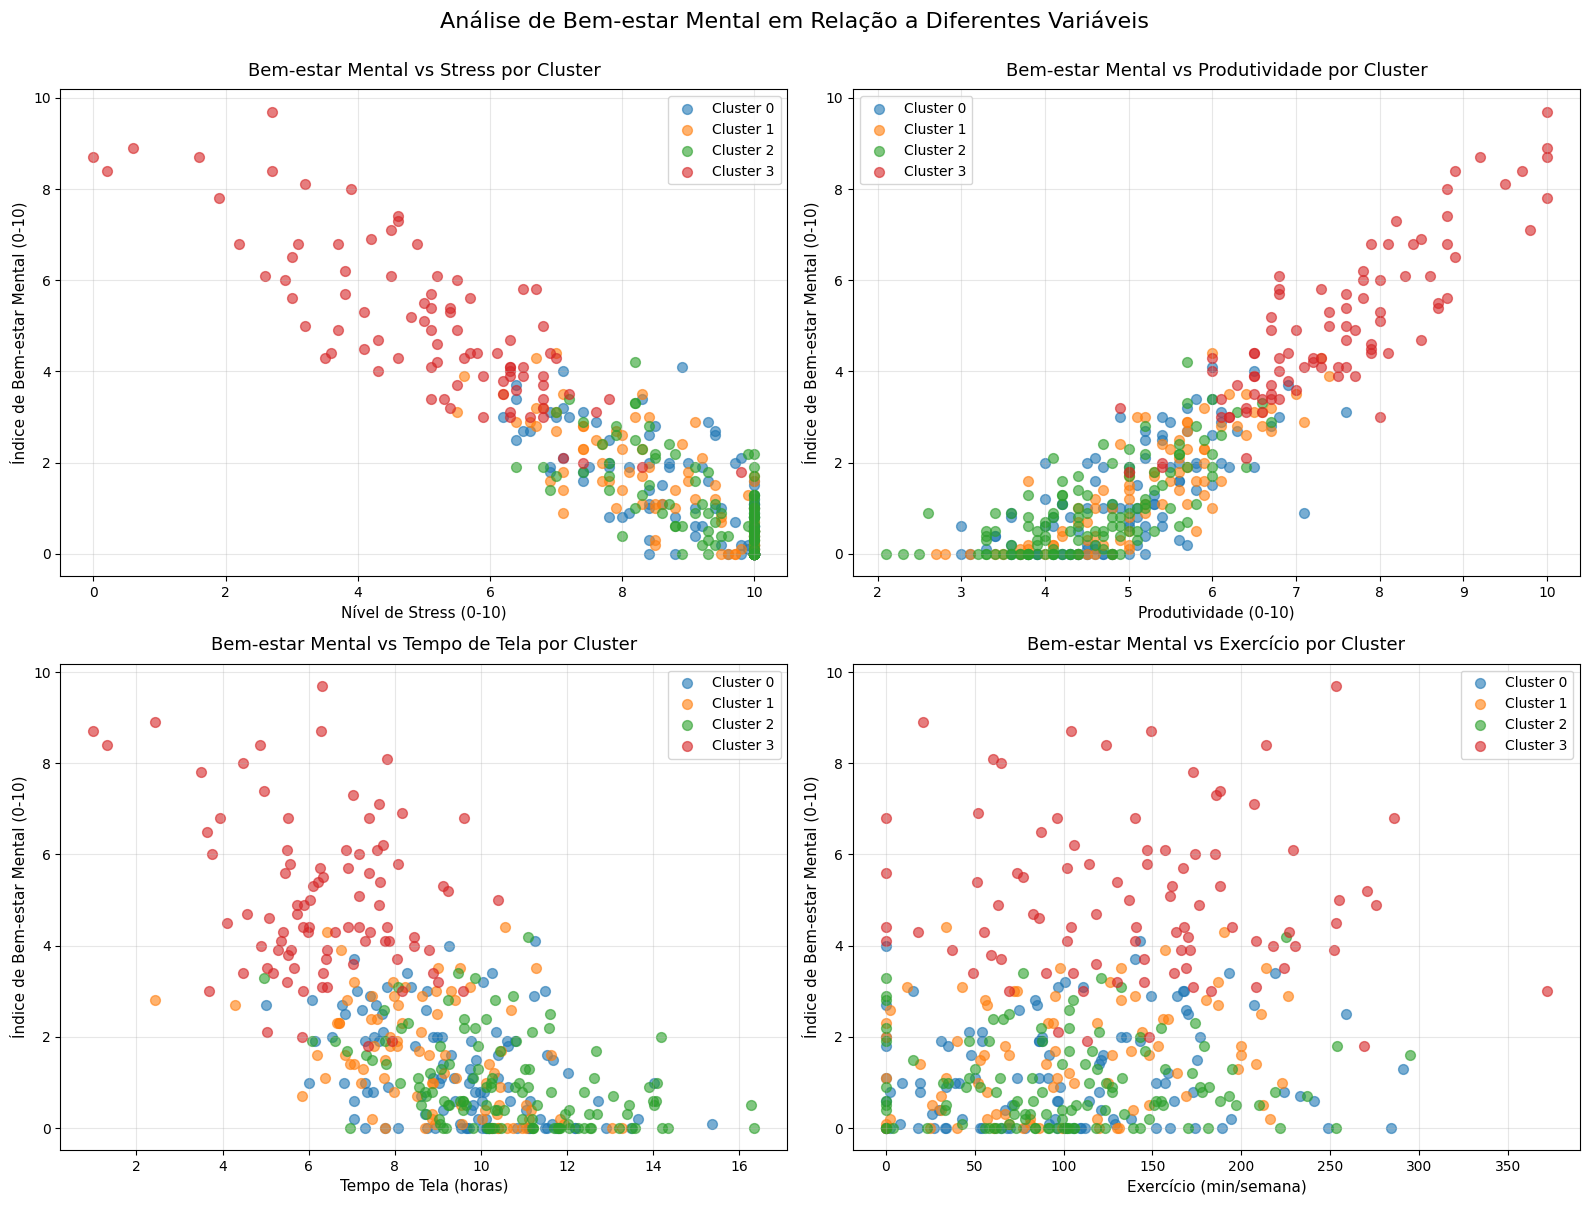

In [69]:
# 10e) Análise de Bem-estar Mental por Cluster - Visualização Detalhada

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Bem-estar vs Stress por cluster
for cluster_id in sorted(df['cluster_habitos_bemestar'].unique()):
    cluster_data = df[df['cluster_habitos_bemestar'] == cluster_id]
    axes[0, 0].scatter(cluster_data['stress_level_0_10'], 
                       cluster_data['mental_wellness_index_0_10'],
                       alpha=0.6, label=f'Cluster {cluster_id}', s=50)

axes[0, 0].set_xlabel('Nível de Stress (0-10)', fontsize=11)
axes[0, 0].set_ylabel('Índice de Bem-estar Mental (0-10)', fontsize=11)
axes[0, 0].set_title('Bem-estar Mental vs Stress por Cluster', fontsize=13, pad=10)
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Produtividade vs Bem-estar por cluster
for cluster_id in sorted(df['cluster_habitos_bemestar'].unique()):
    cluster_data = df[df['cluster_habitos_bemestar'] == cluster_id]
    axes[0, 1].scatter(cluster_data['productivity_0_10'], 
                       cluster_data['mental_wellness_index_0_10'],
                       alpha=0.6, label=f'Cluster {cluster_id}', s=50)

axes[0, 1].set_xlabel('Produtividade (0-10)', fontsize=11)
axes[0, 1].set_ylabel('Índice de Bem-estar Mental (0-10)', fontsize=11)
axes[0, 1].set_title('Bem-estar Mental vs Produtividade por Cluster', fontsize=13, pad=10)
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Tempo de Tela vs Bem-estar por cluster
for cluster_id in sorted(df['cluster_habitos_bemestar'].unique()):
    cluster_data = df[df['cluster_habitos_bemestar'] == cluster_id]
    axes[1, 0].scatter(cluster_data['screen_time_hours'], 
                       cluster_data['mental_wellness_index_0_10'],
                       alpha=0.6, label=f'Cluster {cluster_id}', s=50)

axes[1, 0].set_xlabel('Tempo de Tela (horas)', fontsize=11)
axes[1, 0].set_ylabel('Índice de Bem-estar Mental (0-10)', fontsize=11)
axes[1, 0].set_title('Bem-estar Mental vs Tempo de Tela por Cluster', fontsize=13, pad=10)
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 4. Exercício vs Bem-estar por cluster
for cluster_id in sorted(df['cluster_habitos_bemestar'].unique()):
    cluster_data = df[df['cluster_habitos_bemestar'] == cluster_id]
    axes[1, 1].scatter(cluster_data['exercise_minutes_per_week'], 
                       cluster_data['mental_wellness_index_0_10'],
                       alpha=0.6, label=f'Cluster {cluster_id}', s=50)

axes[1, 1].set_xlabel('Exercício (min/semana)', fontsize=11)
axes[1, 1].set_ylabel('Índice de Bem-estar Mental (0-10)', fontsize=11)
axes[1, 1].set_title('Bem-estar Mental vs Exercício por Cluster', fontsize=13, pad=10)
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.suptitle('Análise de Bem-estar Mental em Relação a Diferentes Variáveis', 
             fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

In [70]:
# 10f) Resumo Interpretativo dos Clusters - Tabela Comparativa

print("\n" + "="*80)
print("RESUMO COMPARATIVO DOS CLUSTERS")
print("="*80)

# Calcular estatísticas por cluster
summary_data = []

for cluster_id in sorted(df['cluster_habitos_bemestar'].unique()):
    cluster_df = df[df['cluster_habitos_bemestar'] == cluster_id]
    
    summary = {
        'Cluster': cluster_id,
        'N_Clientes': len(cluster_df),
        'Screen_Time_Avg': cluster_df['screen_time_hours'].mean(),
        'Sleep_Hours_Avg': cluster_df['sleep_hours'].mean() if 'sleep_hours' in cluster_df.columns else 0,
        'Exercise_Avg': cluster_df['exercise_minutes_per_week'].mean() if 'exercise_minutes_per_week' in cluster_df.columns else 0,
        'Stress_Avg': cluster_df['stress_level_0_10'].mean() if 'stress_level_0_10' in cluster_df.columns else 0,
        'Wellness_Avg': cluster_df['mental_wellness_index_0_10'].mean() if 'mental_wellness_index_0_10' in cluster_df.columns else 0,
        'Productivity_Avg': cluster_df['productivity_0_10'].mean() if 'productivity_0_10' in cluster_df.columns else 0
    }
    summary_data.append(summary)

summary_df = pd.DataFrame(summary_data)

print("\nESTATÍSTICAS MÉDIAS POR CLUSTER:")
print(summary_df.to_string(index=False))

# Identificar características distintivas
print("\n" + "="*80)
print("CARACTERÍSTICAS DISTINTIVAS DE CADA CLUSTER:")
print("="*80)

for cluster_id in sorted(df['cluster_habitos_bemestar'].unique()):
    print(f"\n🔹 CLUSTER {cluster_id}:")
    cluster_df = df[df['cluster_habitos_bemestar'] == cluster_id]
    
    # Ocupação dominante
    if 'occupation' in df.columns:
        occupation_dist = cluster_df['occupation'].value_counts()
        print(f"   • Ocupação dominante: {occupation_dist.index[0]} ({occupation_dist.iloc[0]/len(cluster_df)*100:.1f}%)")
    
    # Modo de trabalho dominante
    if 'work_mode' in df.columns:
        work_mode_dist = cluster_df['work_mode'].value_counts()
        print(f"   • Modo de trabalho: {work_mode_dist.index[0]} ({work_mode_dist.iloc[0]/len(cluster_df)*100:.1f}%)")
    
    # Faixa etária dominante
    if 'age' in df.columns:
        age_dist = cluster_df['age'].value_counts()
        print(f"   • Faixa etária: {age_dist.index[0]} ({age_dist.iloc[0]/len(cluster_df)*100:.1f}%)")
    
    # Nível de bem-estar
    wellness_avg = cluster_df['mental_wellness_index_0_10'].mean() if 'mental_wellness_index_0_10' in cluster_df.columns else 0
    if wellness_avg >= 7:
        wellness_level = "ALTO ⬆️"
    elif wellness_avg >= 5:
        wellness_level = "MÉDIO ➡️"
    else:
        wellness_level = "BAIXO ⬇️"
    print(f"   • Bem-estar mental: {wellness_avg:.2f}/10 - {wellness_level}")
    
    # Nível de stress
    stress_avg = cluster_df['stress_level_0_10'].mean() if 'stress_level_0_10' in cluster_df.columns else 0
    if stress_avg >= 7:
        stress_level = "ALTO ⚠️"
    elif stress_avg >= 4:
        stress_level = "MÉDIO ⚡"
    else:
        stress_level = "BAIXO ✅"
    print(f"   • Nível de stress: {stress_avg:.2f}/10 - {stress_level}")

print("\n" + "="*80)


RESUMO COMPARATIVO DOS CLUSTERS

ESTATÍSTICAS MÉDIAS POR CLUSTER:
 Cluster  N_Clientes  Screen_Time_Avg  Sleep_Hours_Avg  Exercise_Avg  Stress_Avg  Wellness_Avg  Productivity_Avg
       0         109         9.536239         6.739725     99.229358    9.016514      1.189908          4.914679
       1          85         8.838706         6.817059    100.952941    8.567059      1.530588          5.198824
       2         117        10.599145         6.825299    102.769231    9.328205      0.949573          4.547009
       3          88         6.363068         7.794773    141.602273    5.088636      5.015909          7.494318

CARACTERÍSTICAS DISTINTIVAS DE CADA CLUSTER:

🔹 CLUSTER 0:
   • Ocupação dominante: Empregado (83.5%)
   • Modo de trabalho: Hybrid (100.0%)
   • Faixa etária: Adulto_25-50 (75.2%)
   • Bem-estar mental: 1.19/10 - BAIXO ⬇️
   • Nível de stress: 9.02/10 - ALTO ⚠️

🔹 CLUSTER 1:
   • Ocupação dominante: Empregado (60.0%)
   • Modo de trabalho: In-person (90.6%)
   • F

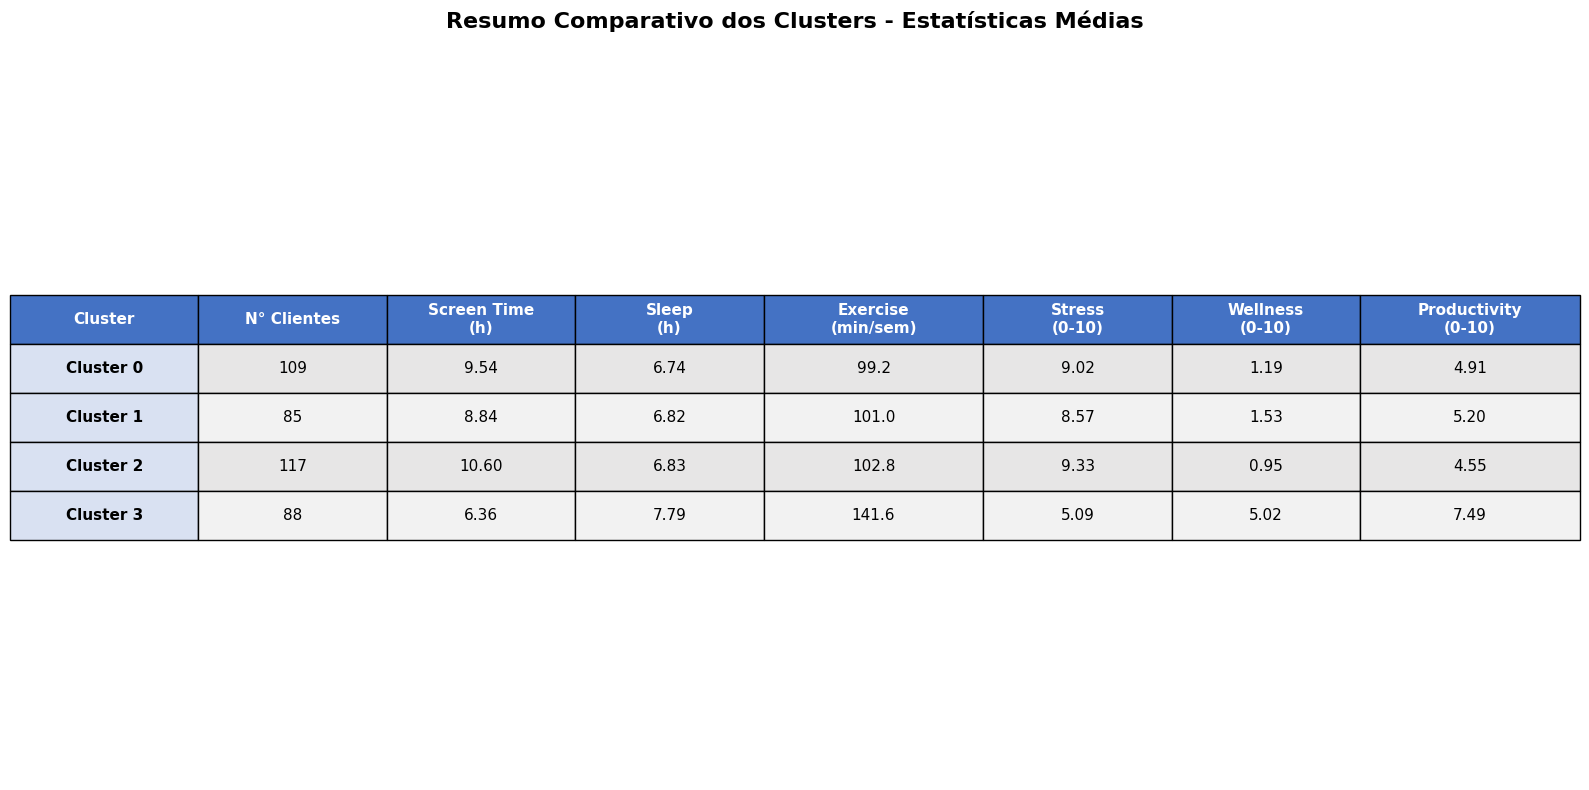

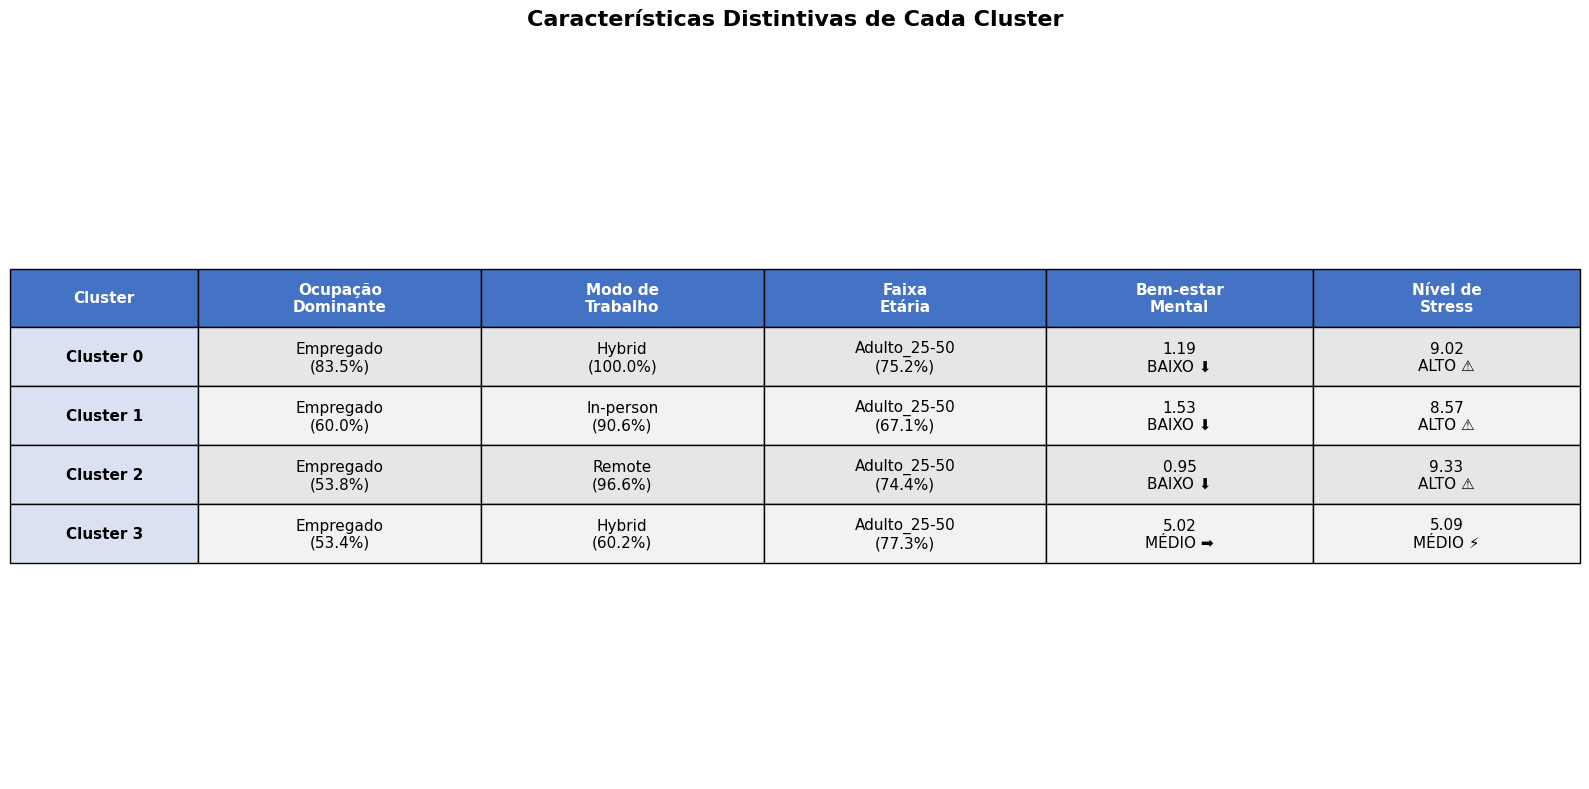

In [72]:
# 10g) Tabela Comparativa Visual - Imagem

# Criar figura para a tabela
fig, ax = plt.subplots(figsize=(16, 8))
ax.axis('tight')
ax.axis('off')

# Preparar dados da tabela
table_data = []
table_headers = ['Cluster', 'N° Clientes', 'Screen Time\n(h)', 'Sleep\n(h)', 
                 'Exercise\n(min/sem)', 'Stress\n(0-10)', 'Wellness\n(0-10)', 'Productivity\n(0-10)']

for cluster_id in sorted(df['cluster_habitos_bemestar'].unique()):
    cluster_df = df[df['cluster_habitos_bemestar'] == cluster_id]
    
    row = [
        f'Cluster {cluster_id}',
        len(cluster_df),
        f"{cluster_df['screen_time_hours'].mean():.2f}",
        f"{cluster_df['sleep_hours'].mean():.2f}" if 'sleep_hours' in cluster_df.columns else 'N/A',
        f"{cluster_df['exercise_minutes_per_week'].mean():.1f}" if 'exercise_minutes_per_week' in cluster_df.columns else 'N/A',
        f"{cluster_df['stress_level_0_10'].mean():.2f}" if 'stress_level_0_10' in cluster_df.columns else 'N/A',
        f"{cluster_df['mental_wellness_index_0_10'].mean():.2f}" if 'mental_wellness_index_0_10' in cluster_df.columns else 'N/A',
        f"{cluster_df['productivity_0_10'].mean():.2f}" if 'productivity_0_10' in cluster_df.columns else 'N/A'
    ]
    table_data.append(row)

# Criar tabela
table = ax.table(cellText=table_data, colLabels=table_headers, 
                cellLoc='center', loc='center',
                colWidths=[0.12, 0.12, 0.12, 0.12, 0.14, 0.12, 0.12, 0.14])

# Estilizar tabela
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Colorir header
for i in range(len(table_headers)):
    table[(0, i)].set_facecolor('#4472C4')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Colorir linhas alternadas
colors = ['#E7E6E6', '#F2F2F2']
for i, row in enumerate(table_data):
    color = colors[i % 2]
    for j in range(len(row)):
        table[(i+1, j)].set_facecolor(color)
        
    # Colorir primeira coluna (Cluster) com cor diferente
    table[(i+1, 0)].set_facecolor('#D9E1F2')
    table[(i+1, 0)].set_text_props(weight='bold')

plt.title('Resumo Comparativo dos Clusters - Estatísticas Médias', 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Criar segunda tabela com características qualitativas
fig2, ax2 = plt.subplots(figsize=(16, 8))
ax2.axis('tight')
ax2.axis('off')

table_data2 = []
table_headers2 = ['Cluster', 'Ocupação\nDominante', 'Modo de\nTrabalho', 
                  'Faixa\nEtária', 'Bem-estar\nMental', 'Nível de\nStress']

for cluster_id in sorted(df['cluster_habitos_bemestar'].unique()):
    cluster_df = df[df['cluster_habitos_bemestar'] == cluster_id]
    
    # Ocupação dominante
    occupation_text = 'N/A'
    if 'occupation' in df.columns:
        occupation_dist = cluster_df['occupation'].value_counts()
        occupation_text = f"{occupation_dist.index[0]}\n({occupation_dist.iloc[0]/len(cluster_df)*100:.1f}%)"
    
    # Modo de trabalho
    work_mode_text = 'N/A'
    if 'work_mode' in df.columns:
        work_mode_dist = cluster_df['work_mode'].value_counts()
        work_mode_text = f"{work_mode_dist.index[0]}\n({work_mode_dist.iloc[0]/len(cluster_df)*100:.1f}%)"
    
    # Faixa etária
    age_text = 'N/A'
    if 'age' in df.columns:
        age_dist = cluster_df['age'].value_counts()
        age_text = f"{age_dist.index[0]}\n({age_dist.iloc[0]/len(cluster_df)*100:.1f}%)"
    
    # Bem-estar
    wellness_avg = cluster_df['mental_wellness_index_0_10'].mean() if 'mental_wellness_index_0_10' in cluster_df.columns else 0
    if wellness_avg >= 7:
        wellness_text = f"{wellness_avg:.2f}\nALTO ⬆️"
    elif wellness_avg >= 5:
        wellness_text = f"{wellness_avg:.2f}\nMÉDIO ➡️"
    else:
        wellness_text = f"{wellness_avg:.2f}\nBAIXO ⬇️"
    
    # Stress
    stress_avg = cluster_df['stress_level_0_10'].mean() if 'stress_level_0_10' in cluster_df.columns else 0
    if stress_avg >= 7:
        stress_text = f"{stress_avg:.2f}\nALTO ⚠️"
    elif stress_avg >= 4:
        stress_text = f"{stress_avg:.2f}\nMÉDIO ⚡"
    else:
        stress_text = f"{stress_avg:.2f}\nBAIXO ✅"
    
    row = [f'Cluster {cluster_id}', occupation_text, work_mode_text, age_text, wellness_text, stress_text]
    table_data2.append(row)

# Criar tabela
table2 = ax2.table(cellText=table_data2, colLabels=table_headers2, 
                  cellLoc='center', loc='center',
                  colWidths=[0.12, 0.18, 0.18, 0.18, 0.17, 0.17])

# Estilizar tabela
table2.auto_set_font_size(False)
table2.set_fontsize(11)
table2.scale(1, 3)

# Colorir header
for i in range(len(table_headers2)):
    table2[(0, i)].set_facecolor('#4472C4')
    table2[(0, i)].set_text_props(weight='bold', color='white')

# Colorir linhas alternadas
for i, row in enumerate(table_data2):
    color = colors[i % 2]
    for j in range(len(row)):
        table2[(i+1, j)].set_facecolor(color)
        
    # Colorir primeira coluna (Cluster) com cor diferente
    table2[(i+1, 0)].set_facecolor('#D9E1F2')
    table2[(i+1, 0)].set_text_props(weight='bold')

plt.title('Características Distintivas de Cada Cluster', 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

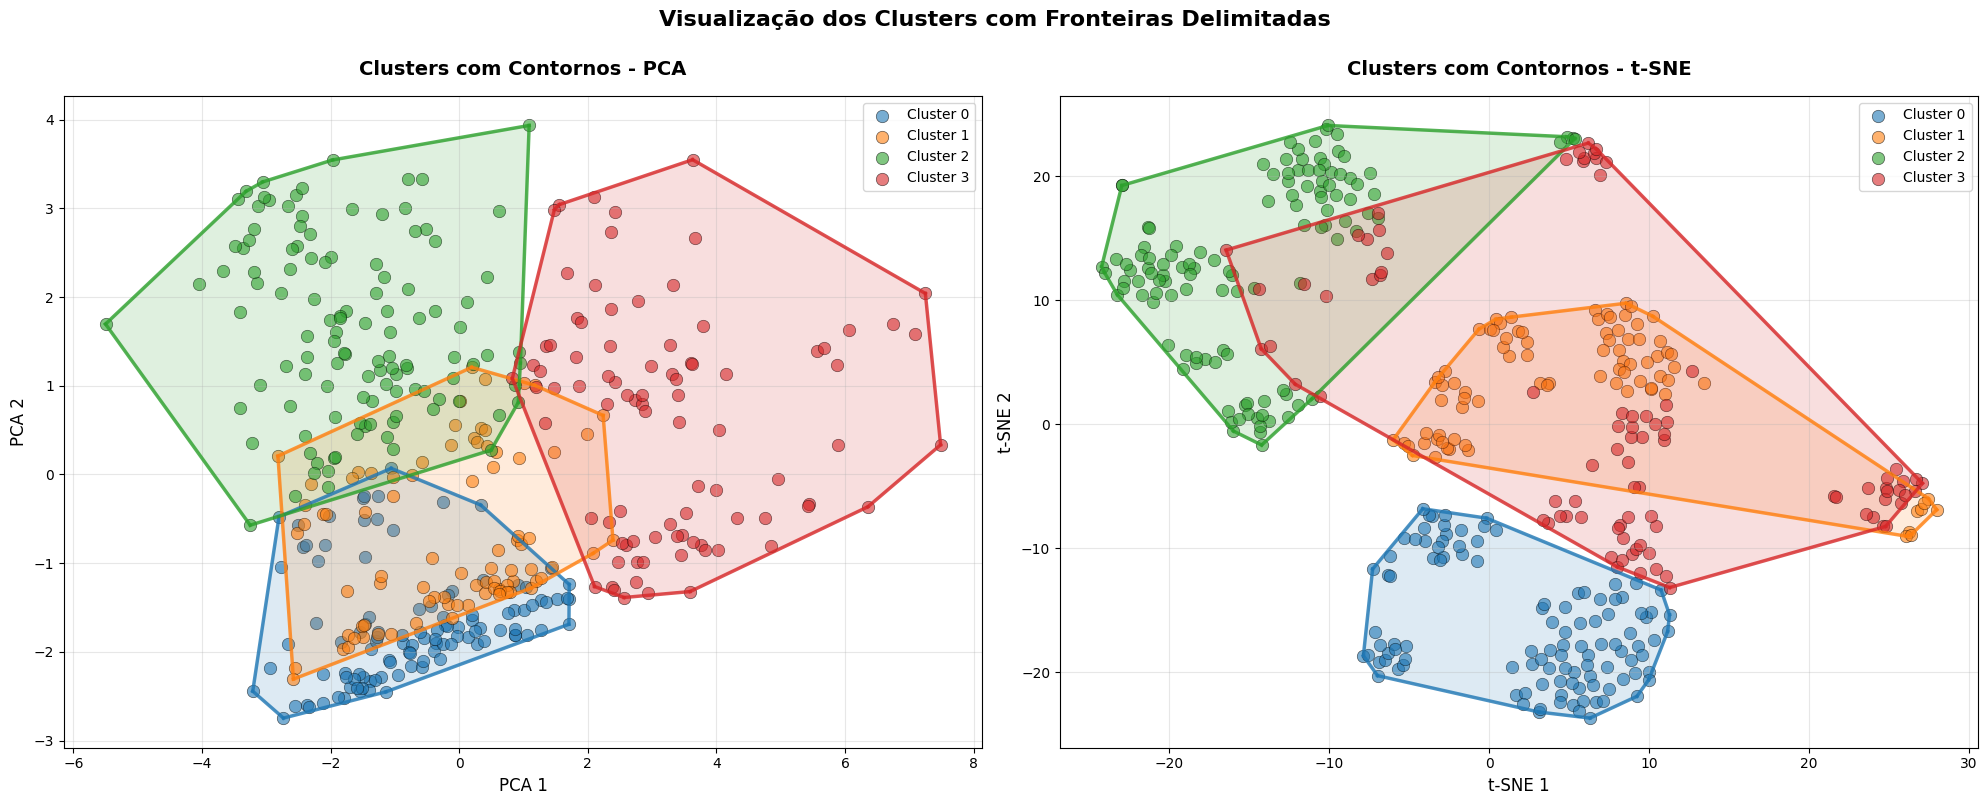

In [73]:
# 11) Visualização dos Clusters com Contornos - PCA e t-SNE

from matplotlib.patches import Ellipse
from scipy.spatial import ConvexHull

def draw_cluster_boundaries(ax, X, y, method_name):
    """Desenha contornos ao redor dos clusters"""
    unique_clusters = sorted(y.unique())
    colors = plt.cm.tab10(range(len(unique_clusters)))
    
    for idx, cluster_id in enumerate(unique_clusters):
        # Pontos do cluster
        cluster_points = X[y == cluster_id]
        
        # Scatter plot
        ax.scatter(cluster_points.iloc[:, 0], cluster_points.iloc[:, 1], 
                  c=[colors[idx]], label=f'Cluster {cluster_id}', 
                  alpha=0.6, s=80, edgecolors='black', linewidth=0.5)
        
        # Desenhar contorno convexo ao redor do cluster
        if len(cluster_points) >= 3:  # Precisa de pelo menos 3 pontos
            try:
                points = cluster_points.values
                hull = ConvexHull(points)
                
                # Desenhar o contorno
                for simplex in hull.simplices:
                    ax.plot(points[simplex, 0], points[simplex, 1], 
                           color=colors[idx], linewidth=2.5, alpha=0.8)
                
                # Preencher a área com transparência
                hull_points = points[hull.vertices]
                ax.fill(hull_points[:, 0], hull_points[:, 1], 
                       color=colors[idx], alpha=0.15)
                
            except:
                pass  # Se não conseguir criar o hull, apenas mostra os pontos
    
    ax.set_title(f'Clusters com Contornos - {method_name}', fontsize=14, fontweight='bold', pad=15)
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel(f'{method_name} 1', fontsize=12)
    ax.set_ylabel(f'{method_name} 2', fontsize=12)

# Criar figura com PCA e t-SNE lado a lado
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# PCA com contornos
pca_data = pd.DataFrame({'x': df['pca1_B'], 'y': df['pca2_B']})
draw_cluster_boundaries(axes[0], pca_data, df['cluster_habitos_bemestar'], 'PCA')

# t-SNE com contornos
tsne_data = pd.DataFrame({'x': df['tsne1_B'], 'y': df['tsne2_B']})
draw_cluster_boundaries(axes[1], tsne_data, df['cluster_habitos_bemestar'], 't-SNE')

plt.suptitle('Visualização dos Clusters com Fronteiras Delimitadas', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

In [ ]:
# 9) Guardar na BD com backup
conn = sqlite3.connect(db_path)

backup_name = f"Backup_ObjB_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
df.to_sql(backup_name, conn, if_exists="replace", index=False)
print(f"Backup com clusters do objetivo B criado: {backup_name}")

df.to_sql(main_table, conn, if_exists="replace", index=False)
conn.close()

print("Tabela principal atualizada com a coluna 'cluster_habitos_bemestar' e coordenadas PCA, UMAP e t-SNE.")

Backup com clusters do objetivo B criado: Backup_ObjB_20251121_104951
Tabela principal atualizada com a coluna 'cluster_habitos_bemestar' e coordenadas PCA (pca1_B, pca2_B).
